In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('..')
from mount_drive import mount_s_drive

In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), 'analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

In [5]:
def getGroupByPatients(myDf, aColumn, aRename):
    return myDf.groupby(aColumn).agg({'patientunitstayid': 'count'}).reset_index().rename(columns={aColumn: aRename, 'patientunitstayid': 'Patients'}).set_index(aRename)

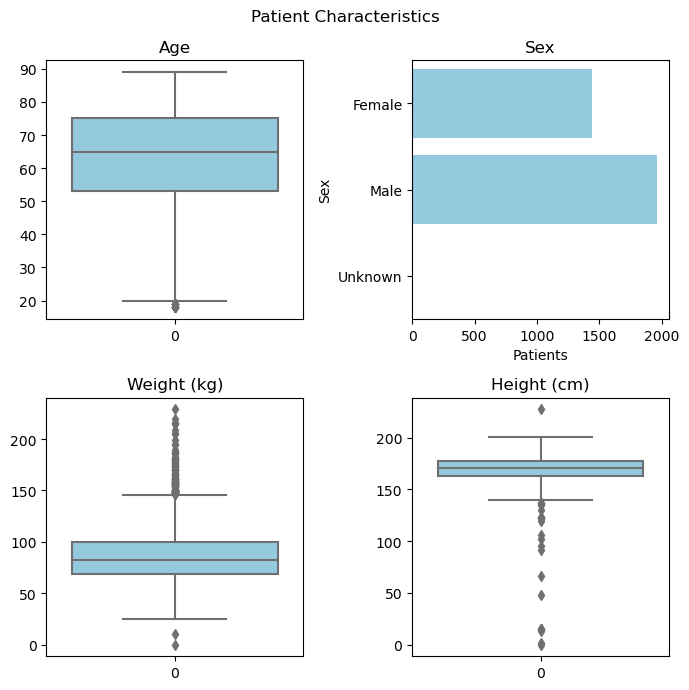

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(7, 7))
sns.boxplot(myPredictorsDf['age'], ax=axs[0][0], color='skyblue')
axs[0][0].set_title('Age')
# sns.boxplot(myPredictorsDf['J0_BMI'], ax=axs[0][1], color='skyblue')
# axs[0][1].set_title('BMI')
sns.boxplot(myPredictorsDf['admissionweight'], ax=axs[1][0], color='skyblue')
axs[1][0].set_title('Weight (kg)')
sns.boxplot(myPredictorsDf['admissionheight'], ax=axs[1][1], color='skyblue')
axs[1][1].set_title('Height (cm)')
myColumn = 'gender'
myRename = 'Sex'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)#.rename({'Homme': 'Male', 'Femme': 'Female'})
sns.barplot(y = 'Sex', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][1], color='skyblue')
axs[0][1].set_title('Sex')
fig.suptitle('Patient Characteristics')
plt.tight_layout()
plt.show()

In [17]:
myColumn = 'rythm'
myRename = 'Rythm'
getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({0:'Unclassified', 3: 'Asystole', 4: 'PEA', 2:'VFib', 1:'VTachy'})

,Patients
Rythm,
Unclassified,2023
VTachy,128
VFib,366
Asystole,293
PEA,595


In [16]:
myPredictorsDf['rythm'] = 0
myPredictorsDf.loc[myPredictorsDf['VTachy'] == 1, 'rythm'] = 1
myPredictorsDf.loc[myPredictorsDf['VFib'] == 1, 'rythm'] = 2
myPredictorsDf.loc[myPredictorsDf['Asystole'] == 1, 'rythm'] = 3
myPredictorsDf.loc[myPredictorsDf['PEA'] == 1, 'rythm'] = 4

In [18]:
myPredictorsDf.groupby(['rythm', 'Hypothermia']).agg({'patientunitstayid':'count'})

patientunitstayid
rythm Hypothermia                   
0     0                         1720
      1                          303
1     0                          115
      1                           13
2     0                          246
      1                          120
3     0                          231
      1                           62
4     0                          503
      1                           92

In [27]:
myGroup = myPredictorsDf.groupby(['FirstGCS']).agg({'patientunitstayid':'count'}).drop('Unable to score due to medication')
myGroup.index = myGroup.index.astype(int)
myGroup.sort_values('FirstGCS').rename(columns={'patientunitstayid':'Count'})

,Count
FirstGCS,
3,1429
4,109
5,110
6,257
7,220
8,170
9,143
10,188
11,182


Text(0.5, 1.0, 'Last mGCS Measurement')

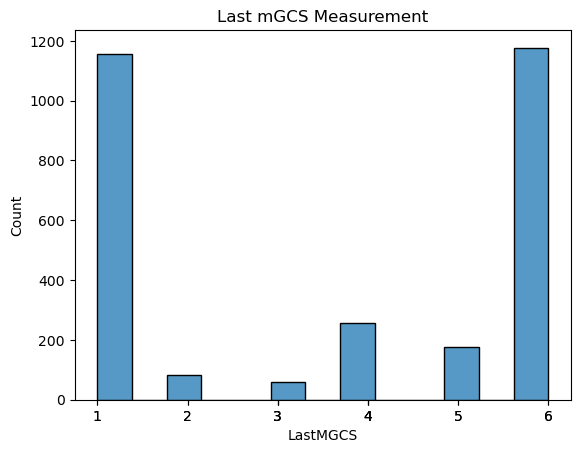

In [7]:
# myGroup = myPredictorsDf.groupby(['LastGCS']).agg({'patientunitstayid':'count'}).drop('Unable to score due to medication')
# myGroup.index = myGroup.index.astype(int)
# myGroup.sort_values('LastGCS').rename(columns={'patientunitstayid':'Count'}, inplace=True)#.plot.hist()
myFilter = (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myPredictorsDf = myPredictorsDf[myFilter]
myPredictorsDf['LastMGCS'] = myPredictorsDf['LastMGCS'].astype(int)
bin_counts, bin_edges = np.histogram(myPredictorsDf['LastMGCS'], bins='auto')
ax = sns.histplot(data=myPredictorsDf, x='LastMGCS', kde=False)
# bin_edges = ax.patches[0].get_xdata()
plt.xticks(np.round(bin_edges))
plt.title('Last mGCS Measurement')

In [45]:
bin_edges

array([ 3.        ,  3.92307692,  4.84615385,  5.76923077,  6.69230769,
        7.61538462,  8.53846154,  9.46153846, 10.38461538, 11.30769231,
       12.23076923, 13.15384615, 14.07692308, 15.        ])

In [55]:
myGroup = myPredictorsDf.groupby(['LastGCSGt8', 'DeathAtDischarge']).agg({'patientunitstayid':'count'})#.drop('Unable to score due to medication')
# myGroup.index = myGroup.index.astype(int)
myGroup.sort_values('LastGCSGt8').rename(columns={'patientunitstayid':'Count'})

Count
LastGCSGt8 DeathAtDischarge       
False      0                   260
           1                  1446
True       0                  1287
           1                   240

In [53]:
myPredictorsDf['LastGCSGt8'] = myPredictorsDf.LastGCS > 8